In [59]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split

In [60]:
df = sns.load_dataset("titanic")

In [61]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [62]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [63]:
features = ["sex" , "pclass","fare","embarked","age"]
target = ["survived"]

In [64]:
from sklearn.impute import SimpleImputer
imputer_median= SimpleImputer(strategy = "median")
df[["age"]] = imputer_median.fit_transform(df[["age"]])
imputer_most_freq = SimpleImputer(strategy = "most_frequent")
df[["embarked"]]=imputer_most_freq.fit_transform(df[["embarked"]])

In [65]:
from sklearn.preprocessing import LabelEncoder , OneHotEncoder
le = LabelEncoder()
df["sex"]=le.fit_transform(df["sex"])
df["embarked"]=le.fit_transform(df["embarked"])

In [66]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [67]:
X = df[features]
y = df[target]

In [68]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42)

In [35]:
from sklearn.tree import DecisionTreeClassifier

In [37]:
model = DecisionTreeClassifier()
model.fit(X_train , y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [38]:
y_pred = model.predict(X_test)

In [41]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test,y_pred)
acc

0.7597765363128491

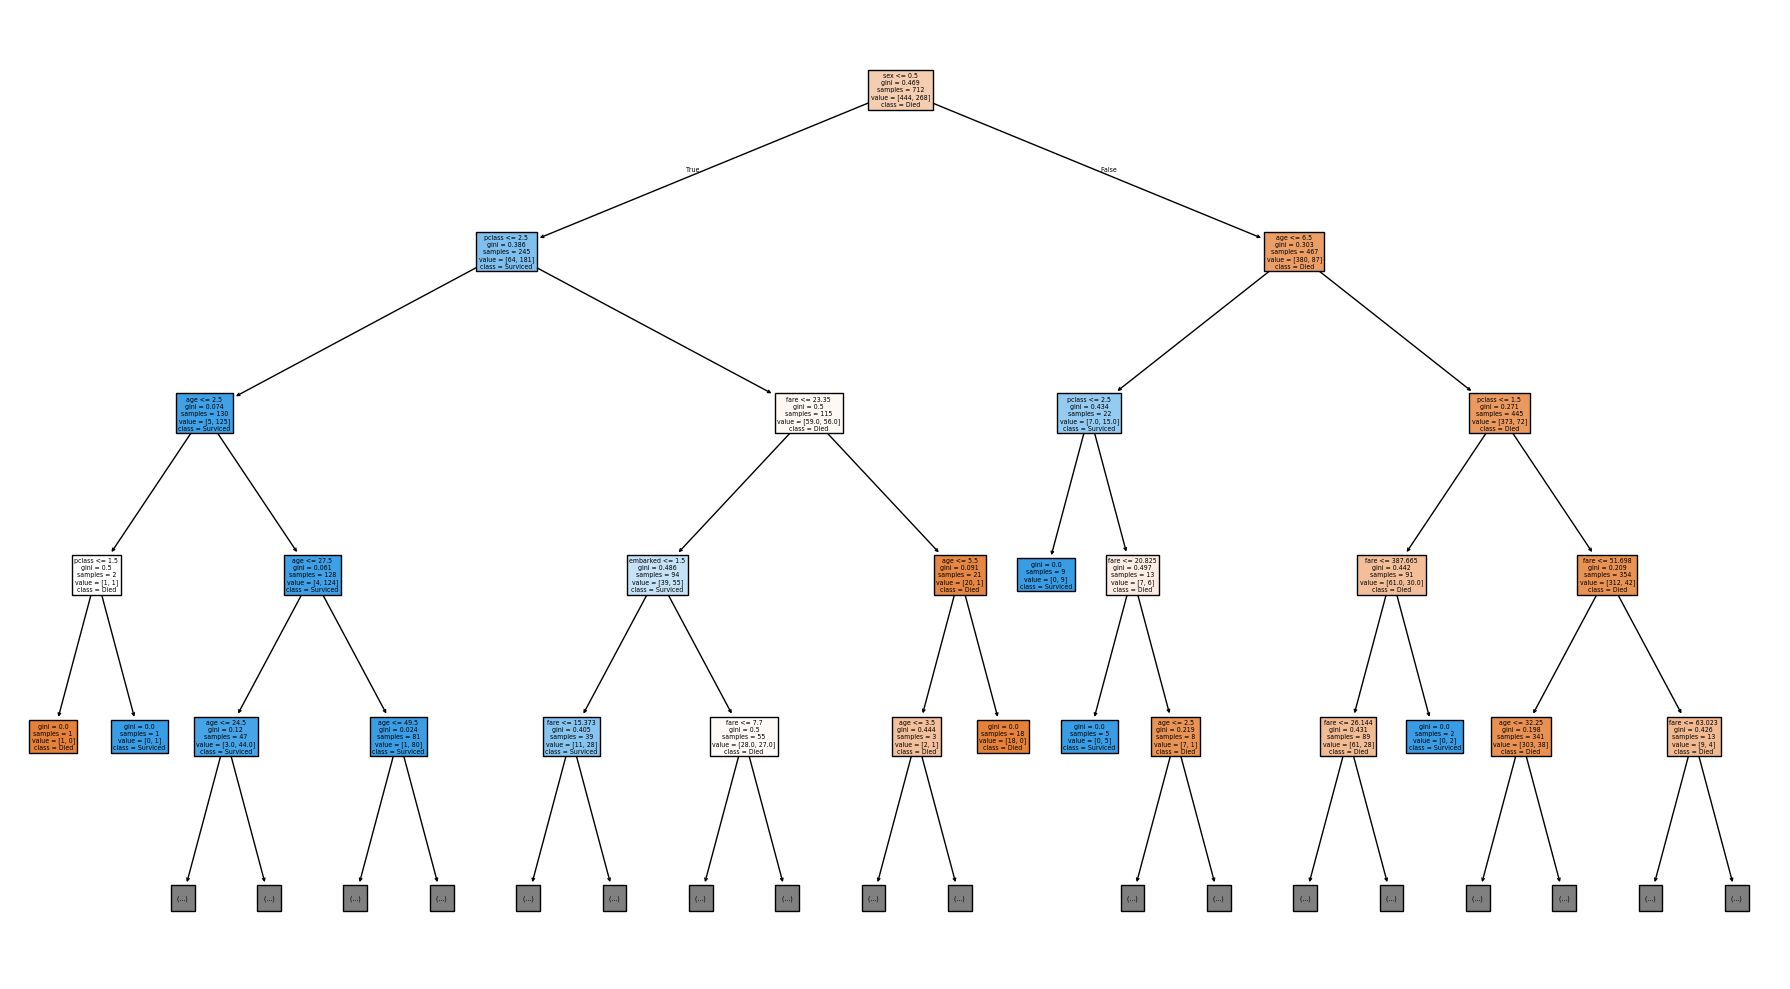

In [51]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree (
    model,
    feature_names = X.columns,
    class_names = ["Died","Surviced"],
    filled = True,
    max_depth = 4
)
plt.tight_layout()
plt.show()

DECISION TREE PRUNING

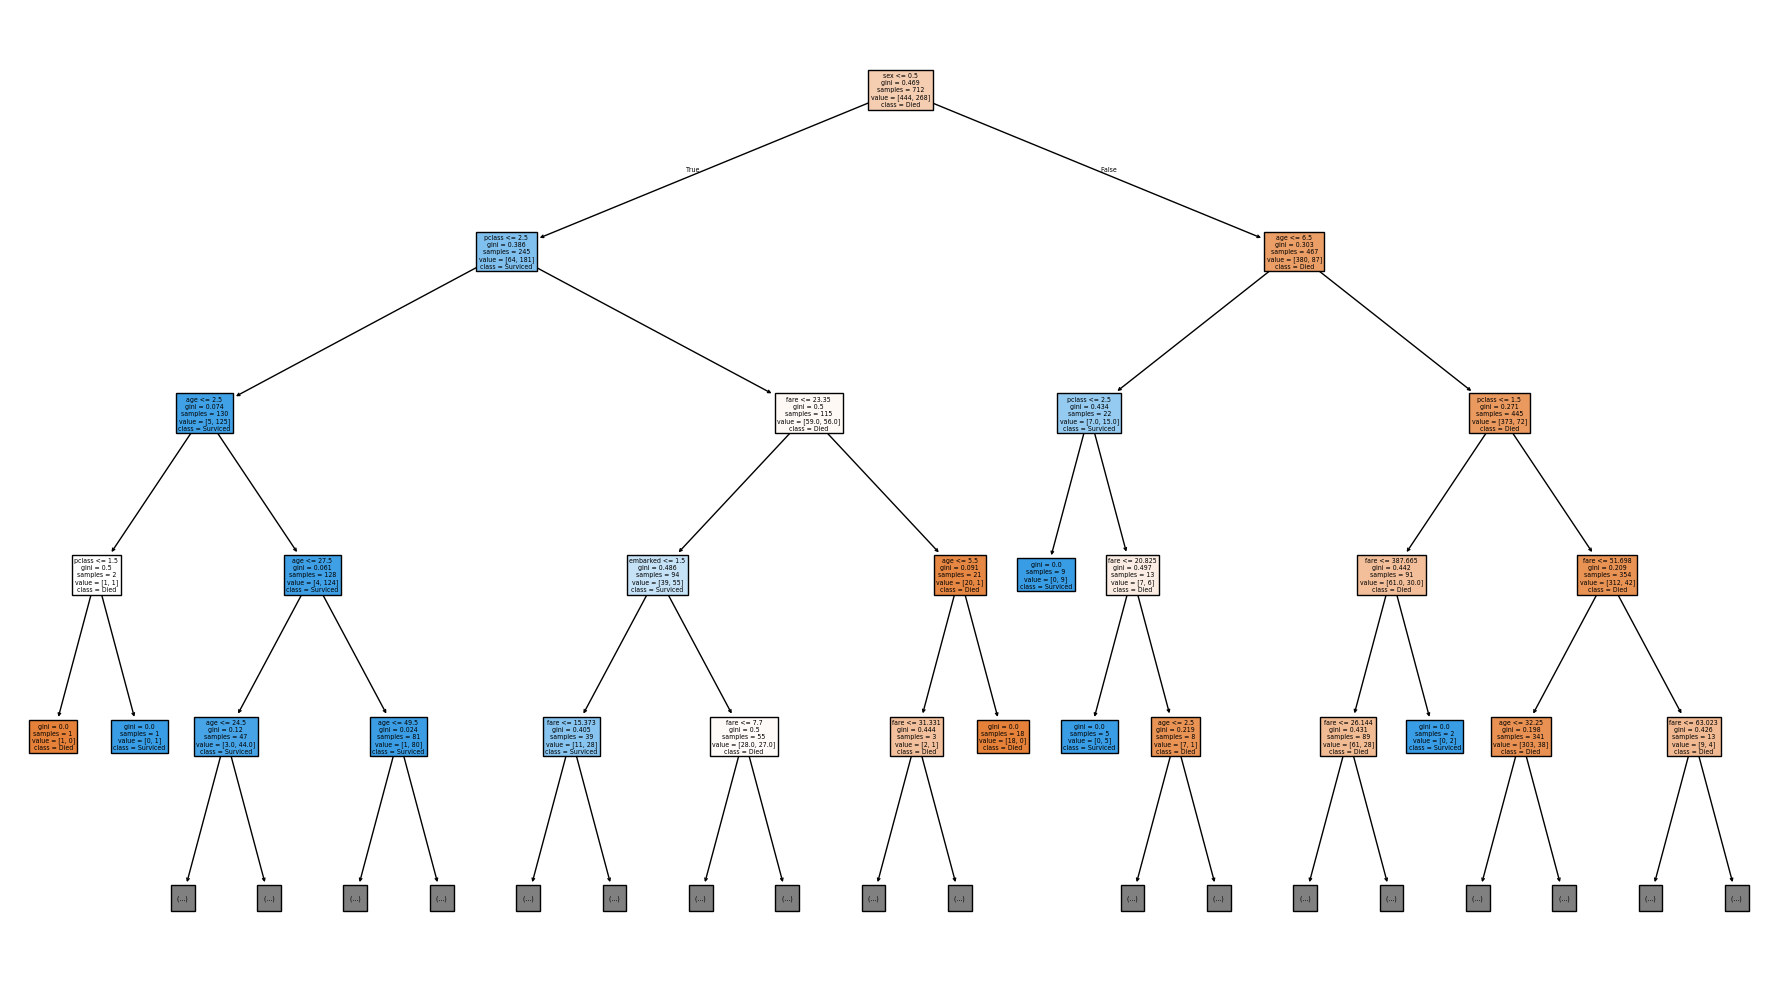

In [72]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree (
    model,
    feature_names = X.columns,
    class_names = ["Died","Surviced"],
    filled = True,
    max_depth = 4
)
plt.tight_layout()
plt.show()
    

In [78]:
min_sample_splits = [5,10,15,20,25,30,35]
for splits in min_sample_splits:
    model = DecisionTreeClassifier(max_depth=4,min_samples_split = splits)
    model.fit(X_train , y_train)
    
    acc = model.score(X_test,y_test)
    print(f"for split={splits} accuracy={acc}")

for split=5 accuracy=0.7988826815642458
for split=10 accuracy=0.7988826815642458
for split=15 accuracy=0.7988826815642458
for split=20 accuracy=0.7988826815642458
for split=25 accuracy=0.7932960893854749
for split=30 accuracy=0.7932960893854749
for split=35 accuracy=0.7932960893854749


PRE PRUNING TREE

In [79]:
full_tree = DecisionTreeClassifier(random_state = 42)
full_tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [82]:
path = full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alpha = path.ccp_alphas
ccp_alpha

array([0.00000000e+00, 0.00000000e+00, 6.68806849e-05, 1.45921494e-04,
       1.84428555e-04, 2.00642055e-04, 2.34082397e-04, 2.34082397e-04,
       2.34082397e-04, 3.51123596e-04, 4.68164794e-04, 4.68164794e-04,
       5.61797753e-04, 6.24219725e-04, 6.67991230e-04, 7.02247191e-04,
       7.02247191e-04, 8.19288390e-04, 8.19288390e-04, 8.32292967e-04,
       8.42696629e-04, 8.42696629e-04, 8.94231048e-04, 8.99610781e-04,
       9.24769963e-04, 9.36329588e-04, 9.36329588e-04, 9.36329588e-04,
       9.88347898e-04, 1.00253471e-03, 1.02996255e-03, 1.05337079e-03,
       1.07400895e-03, 1.08038029e-03, 1.11865144e-03, 1.12359551e-03,
       1.12359551e-03, 1.13139825e-03, 1.18841832e-03, 1.22566125e-03,
       1.22893258e-03, 1.22893258e-03, 1.24361593e-03, 1.24843945e-03,
       1.27565833e-03, 1.30996111e-03, 1.33761370e-03, 1.37044603e-03,
       1.47927070e-03, 1.51142557e-03, 1.54072312e-03, 1.56675436e-03,
       1.60434338e-03, 1.66892062e-03, 1.75561798e-03, 1.76144762e-03,
      

In [85]:
trees = []
for alphas in ccp_alpha:
    model = DecisionTreeClassifier(random_state = 42 , ccp_alpha = alphas)
    model.fit(X_train,y_train)
trees.append((model,alphas))

In [92]:
best_alpha = 0
best_acc = 0
for model, alphas in trees:
    curr_acc = model.score(X_test,y_test)
if curr_acc > best_acc:
    best_acc = curr_acc
best_alpha = alphas

In [93]:
best_acc

0.5865921787709497

In [94]:
best_alpha


0.5865921787709497